In [2]:
import pandas as pd
import mne
import pyxdf
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path

## Load EEG files

In [21]:
# Find and read 0-back annotated EEG FIF files
repo_root = Path.cwd()
while not (repo_root / "data").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

annot_dir = repo_root / "data" / "0-back" / "eeg"
annot_files = sorted(annot_dir.rglob("*_annot_raw.fif"))

print(f"Annotated directory: {annot_dir}")
print(f"Found {len(annot_files)} annotated files")
for f in annot_files:
    print("-", f.relative_to(repo_root))

# Load all files into memory (keyed by subject ID)
raw_annot_by_subject = {}
for f in annot_files:
    match = re.search(r"sub-(P\d+)", f.name)
    subj = match.group(1) if match else f.stem
    raw_annot_by_subject[subj] = mne.io.read_raw_fif(f, preload=False, verbose="ERROR")

print(f"Loaded {len(raw_annot_by_subject)} Raw objects")
print("Subjects:", sorted(raw_annot_by_subject.keys()))

# Quick peek at one recording
if raw_annot_by_subject:
    first_subj = sorted(raw_annot_by_subject.keys())[0]
    display(raw_annot_by_subject[first_subj])

Annotated directory: c:\Users\n.saleem\Documents\GitHub\0x2x2dual_WCST_analysis\data\0-back\eeg
Found 4 annotated files
- data\0-back\eeg\sub-P001\ses-S001\eeg\sub-P001_ses-S001_task-Default_run-001_eeg_annot_raw.fif
- data\0-back\eeg\sub-P002\ses-S001\eeg\sub-P002_ses-S001_task-Default_run-001_eeg_annot_raw.fif
- data\0-back\eeg\sub-P003\ses-S001\eeg\sub-P003_ses-S001_task-Default_run-001_eeg_annot_raw.fif
- data\0-back\eeg\sub-P004\ses-S001\eeg\sub-P004_ses-S001_task-Default_run-001_eeg_annot_raw.fif
Loaded 4 Raw objects
Subjects: ['P001', 'P002', 'P003', 'P004']


<Raw | sub-P001_ses-S001_task-Default_run-001_eeg_annot_raw.fif, 20 x 613243 (1226.5 s), ~30 KiB, data not loaded>

## Downsample all annotated EEG files

In [22]:
# Downsample all loaded subjects to a common sampling frequency
target_sfreq = 250  # Hz

if "raw_annot_by_subject" not in globals() or not raw_annot_by_subject:
    raise RuntimeError("Run the previous cell that loads annotated files first.")

raw_ds_by_subject = {}
summary_rows = []

for subj, raw in sorted(raw_annot_by_subject.items()):
    original_sfreq = float(raw.info["sfreq"])
    # raw.copy().load_data() is required because resampling needs data in memory
    raw_ds = raw.copy().load_data().resample(sfreq=target_sfreq, npad="auto")
    raw_ds_by_subject[subj] = raw_ds

    summary_rows.append({
        "subject": subj,
        "original_sfreq": original_sfreq,
        "downsampled_sfreq": float(raw_ds.info["sfreq"]),
        "n_samples_after": raw_ds.n_times
    })

downsample_summary = pd.DataFrame(summary_rows)
display(downsample_summary)
print(f"Downsampled {len(raw_ds_by_subject)} subjects to {target_sfreq} Hz")

Reading 0 ... 613242  =      0.000 ...  1226.484 secs...


Reading 0 ... 620742  =      0.000 ...  1241.484 secs...
Reading 0 ... 602988  =      0.000 ...  1205.976 secs...
Reading 0 ... 595982  =      0.000 ...  1191.964 secs...


,subject,original_sfreq,downsampled_sfreq,n_samples_after
0,P001,500.0,250.0,306622
1,P002,500.0,250.0,310372
2,P003,500.0,250.0,301494
3,P004,500.0,250.0,297992


Downsampled 4 subjects to 250 Hz


## Plot one subject (downsampled raw)

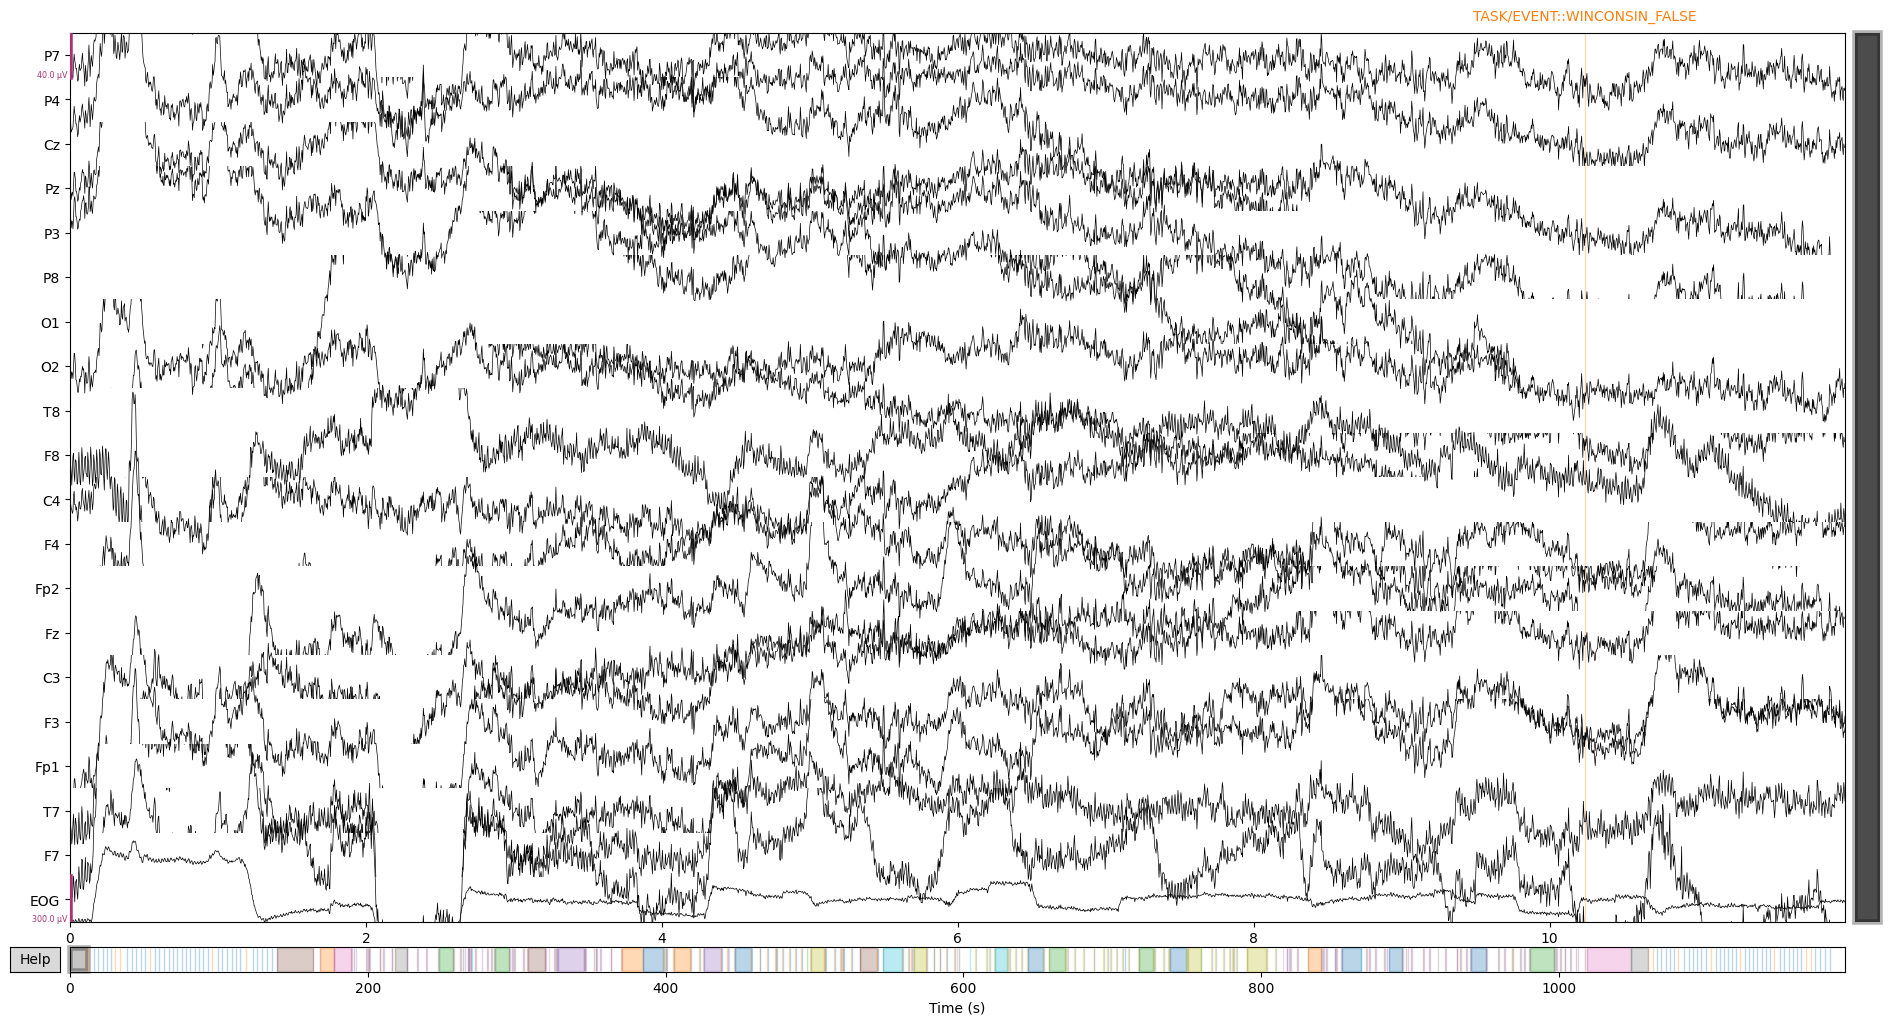

In [23]:
subject_to_plot = "P004"

raw_plot = raw_ds_by_subject[subject_to_plot]

raw_plot.plot(
    duration=12,
    n_channels=20,
    show=True,
);

## bp filter 1 - 40 hz

In [30]:
# Apply band-pass filter to all downsampled subjects
l_freq = 1.0
h_freq = 40.0

if "raw_ds_by_subject" not in globals() or not raw_ds_by_subject:
    raise RuntimeError("Run the downsampling cell first.")

raw_bp_by_subject = {}
filter_summary_rows = []

for subj, raw in sorted(raw_ds_by_subject.items()):
    raw_bp = raw.copy().filter(
        l_freq=l_freq,
        h_freq=h_freq,
        fir_design="firwin",
        verbose="ERROR"
    )
    raw_bp_by_subject[subj] = raw_bp

    filter_summary_rows.append({
        "subject": subj,
        "sfreq": float(raw_bp.info["sfreq"]),
        "l_freq": l_freq,
        "h_freq": h_freq,
        "n_samples": raw_bp.n_times
    })

filter_summary = pd.DataFrame(filter_summary_rows)
display(filter_summary)

,subject,sfreq,l_freq,h_freq,n_samples
0,P001,250.0,1.0,40.0,306622
1,P002,250.0,1.0,40.0,310372
2,P003,250.0,1.0,40.0,301494
3,P004,250.0,1.0,40.0,297992


## Plot after bp filter

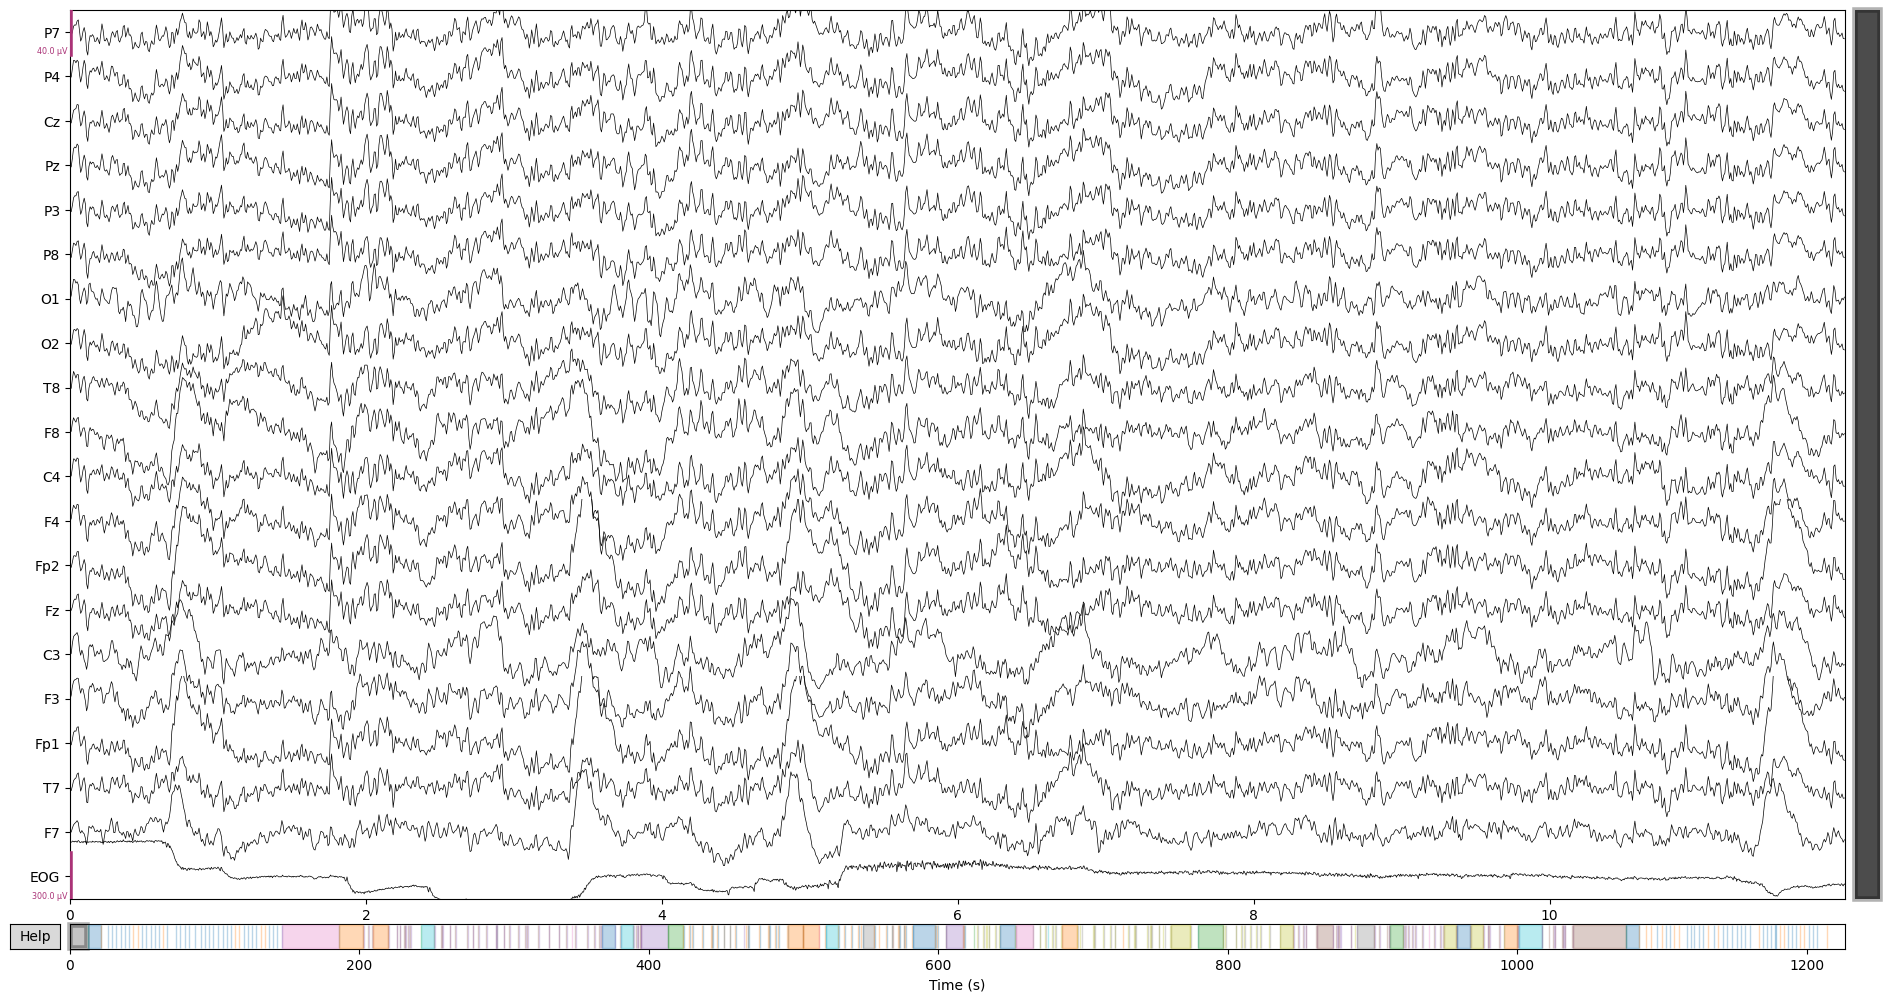

In [31]:
subject_to_plot_bp = "P001"

available_subjects_bp = sorted(raw_bp_by_subject.keys())
raw_bp_plot = raw_bp_by_subject[subject_to_plot_bp]
raw_bp_plot.plot(
    duration=12,
    n_channels=20,
    show=True,
);